# Week 6

[Good news everyone!](https://www.youtube.com/watch?v=vLxMB8xmWSI) We've had heavy exercise load the last few weeks, so it's time for an lighter day today `:)`

The purpose of today's class is to explore data using **interactive visualizations**. Interactivity is a key part of modern dataviz. It lets users of your visualizations get their own feel for the data, creating richer experiences where people can expose more of the data by exploring.

## Today

This lecture covers:

1. **Explanatory data visualization**: A video lecture on the principles of interactive, explanatory dataviz: overview first, zoom and filter, details on demand.
2. **Interactive visualizations with Plotly**: You'll rebuild the hourly crime distributions from Week 2 as interactive plots, and then take things further with animated visualizations.
3. **Narrative data visualization**: Reading from a key research paper on how to tell stories with data.

## Part 1: Explanatory Data Visualization

Starting this week, we'll be playing around with *explanatory data visualization*. Roughly speaking, this means using data visualization to communicate your results to others. Thus, there are new things to think about.

Until today we have worked with static data visualization. However, exploratory data analysis means being able to explore the multi-faceted nature of data, and *interactive dataviz* is a handy tool to do it! It allows the user to play with the data without knowing how to write code: toggle the view, zoom, drag, show more details. These are a key part of modern data visualization.

The video below provides context about these points.

We start with the video and then read a bit from a scientific article about types of explanatory dataviz. (*The video is from an old version of the class that used D3, so just ignore those parts.*)

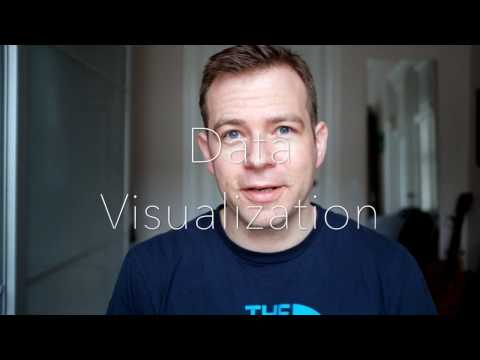

In [1]:
from IPython.display import YouTubeVideo
YouTubeVideo('yHKYMGwefso', width=800, height=450)

> *Exercise 1.1*: Explanatory data visualization.
> * What are the three key elements to keep in mind when you design an explanatory visualization?

The three key things I would keep in mind are the following. First, **start with a question**: an explanatory visualization should not just display data, but communicate a specific result, comparison, or message. Second, **allow exploration**: even if the visualization is explanatory, the reader should still be able to inspect the data, for example by hovering, filtering, zooming, or toggling categories. Third, **know your readers**: the design should depend on the audience, because what is clear and useful for an expert may be confusing or overwhelming for a general reader. So overall, explanatory visualization is not just about showing data nicely, but about guiding the audience toward a point while still giving them room to interact with the evidence.

> * In the video I talk about (1) *overview first*, (2) *zoom and filter*, (3) *details on demand*.
>   - Go online and find a visualization that follows these principles (don't use one from the video).
>   - Explain how your example achieves (1)-(3). It might be useful to use screenshots to illustrate your explanation.

A good example is the [Our World in Data CO₂ and Greenhouse Gas Emissions Explorer](https://ourworldindata.org/explorers/co2). It gives an **overview first** by showing a broad global view of emissions data across countries and indicators. It supports **zoom and filter** because the user can select countries, change indicators, switch chart types, and restrict the time period. It provides **details on demand** through hover tooltips, highlighted country traces, axis values, and source metadata when you interact with the chart. So it starts broad, then becomes specific as the reader asks for more.

> * Explain in your own words: How is explanatory data analysis different from exploratory data analysis?

Explanatory data analysis is different from exploratory data analysis because the goal is different. In **exploratory** analysis, you are trying to learn from the data yourself, test ideas, and discover patterns you did not know beforehand. In **explanatory analysis**, you already have a point or story you want to communicate, so the visualization is designed to guide another person toward that understanding. Exploratory plots are often rough and analyst-centered, while explanatory plots are more selective, structured, and audience-centered.

>
> **Note**. Keep your answers to the questions above short and sweet.

<div class="alert alert-block alert-info">
Try to answer these using your human brain, don't use an LLM.
</div>

## Part 2: Interactive Visualizations with Plotly

You already know Plotly from Week 5, where you used it to create choropleth maps. Now we'll use it for a different purpose: building interactive charts that let users explore temporal patterns in the crime data.

Plotly is great for this because it gives you interactivity for free: hover tooltips, zoom, pan, and clickable legends all come built-in. This means you can focus on the *data* and the *story*, not on wiring up interactive widgets.

If you need a refresher, the [Plotly Express documentation](https://plotly.com/python/plotly-express/) is a good starting point. But I hope you'll find that you remember more from Week 5 than you think 🤟

**Note**: There are many other ways to create interactive visualizations. I'll highlight two

* *[Altair](https://altair-viz.github.io/)*
* *[Bokeh](https://docs.bokeh.org/en/latest/)* (Bokeh is nice when you want a bit more lower-level control in Python, we've used this in the class previously).

If you want to use these when we get further in the class and you're creating your  own visualizations in the final project, that is OK.

Anyway. **Let's get started**. As always we'll focus on the SF crime data, and your personal focus crimes. Data for whole years only.

The goal is to create an *interactive* visualization of how your Personal Focus Crimes distribute across the 24 hours of the day — similar to what you plotted in Week 2's Exercise 3.1, but now set up so the user can play with the data. The key feature: you can click on crime types in the legend to show and hide them, making it possible to directly compare patterns across crime types.

> *Exercise 2.1*: New version weekly patterns. To complete the exercise, follow the steps below.

<div class="alert alert-block alert-info">
Try to do this yourself before asking an LLM — you already know Plotly from Week 5, and the data preparation is similar to what you did in Week 2. Use your LLM as a helper if you get stuck, not as an end-to-end solution.
</div>

> ### Data prep
>
> A key step is to set up the data right. I recommend the following workflow:
>
> 1. Take the data for the period you want to plot, group it by hour-of-the-day for each of your Personal Focus Crimes. We'll use the entire period by default, but you may use another period if you'd like.
> 2. We want to compare *shapes* of distributions across crime types, not absolute numbers, so we'll work on **normalized data**:
>    * To normalize within a crime category, divide the count for each hour by the total number of that crime type. (For example, in the `Drug Offense` category, take the count of drug offenses in the midnight-to-1am hour and divide by the total number of drug offenses across all hours, etc)
>    * Note that when you normalize the data, you can interpret your data as a probability distribution, where each hour shows the probability that a crime will happen at that time.
>    * Your life will be easiest if you organize your data in **long format** — a DataFrame with columns like `Hour`, `CrimeType`, and `NormalizedCount`. If you have it in wide format (one column per crime type), look into [`pd.melt()`](https://pandas.pydata.org/docs/reference/api/pandas.melt.html) to reshape it.
>


In [3]:
import pandas as pd
import plotly.express as px
from pathlib import Path
merged_path = Path(r"C:\Users\slupo\OneDrive\Documentos\DTU\Social data analysis and visualization") / "sf_crime_merged_focus_2003_2025.csv"
df = pd.read_csv(merged_path, low_memory=False)
import pandas as pd

df["date"] = pd.to_datetime(df["date"], format="%Y-%m-%d", errors="coerce").dt.date
df["time"] = df["time"].astype(str).str.strip()
df["datetime"] = pd.to_datetime(df["datetime"], format="%Y-%m-%d %H:%M:%S", errors="coerce")
df["year"] = pd.to_numeric(df["year"], errors="coerce").astype("Int64")

In [4]:
crime_col = 'category'
time_col = 'datetime'
df['Hour'] = df[time_col].dt.hour

hourly_counts = (
    df.groupby([crime_col, 'Hour'])
    .size()
    .rename('Count')
    .reset_index()
)

hourly_counts['NormalizedCount'] = (
    hourly_counts['Count']
    / hourly_counts.groupby(crime_col)['Count'].transform('sum')
)

# Step 5: final long-format dataframe ready for Plotly
plot_ready = hourly_counts.rename(columns={crime_col: 'CrimeType'})[
    ['Hour', 'CrimeType', 'NormalizedCount']
]

plot_ready.head(10)

,Hour,CrimeType,NormalizedCount
0,0,ARSON,0.062770
1,1,ARSON,0.060687
2,2,ARSON,0.065744
3,3,ARSON,0.061133
4,4,ARSON,0.057266
5,5,ARSON,0.046854
6,6,ARSON,0.037037
7,7,ARSON,0.027964
8,8,ARSON,0.028707
9,9,ARSON,0.024840


> ### Creating the plot
>
> You'll use `px.bar` from Plotly Express — the same library you used for choropleth maps in Week 5. A few things to think about:
>
> * With many crime types, placing bars side-by-side for each hour produces tiny, unreadable bars. Look into Plotly's different [`barmode`](https://plotly.com/python/bar-charts/) options for a better approach. Adding some transparency will help when bars overlap.
> * The plot is more useful if it starts "empty" (all data/traces hidden) so the user can build up comparisons by clicking legend items one at a time. Look into Plotly's `visible` trace property to achieve this.
> * If all traces start hidden, Plotly has no data to auto-scale from, so your axes will not be meaningful. You'll need to set `range_x` and `range_y` explicitly. Think about what sensible values would be for 24 hours of data with normalized counts.
> * Place the legend where it doesn't obscure the data or the axis tick values. <font color=gray>It's OK to ask your LLM for help with legend placement.</font>
>
> It's hard to explain what I'm looking for, so here's my version so you have an idea. You plot doesn't have to look exactly like that, it's just so you have a sense of what I'm looking for and a picture's worth 1000 words.
> 
> ![example gif](https://raw.githubusercontent.com/suneman/socialdata2026/main/files/example.gif)
> 

In [9]:
# Use px.bar as requested in the instructions.
fig = px.bar(
    plot_ready,
    x='Hour',
    y='NormalizedCount',
    color='CrimeType',
    barmode='overlay',  # Instruction: use a better barmode than side-by-side for many crime types.
    opacity=0.65,       # Instruction: add transparency to help when bars overlap.
    title='Normalized hourly distribution of personal focus crimes',
    labels={
        'Hour': 'Hour of Day',
        'NormalizedCount': 'Normalized Count',
        'CrimeType': 'Crime Type'
    },
    range_x=[-0.5, 23.5],  # Instruction: set range_x explicitly because all traces start hidden.
    range_y=[0, 0.25]      # Instruction: set range_y explicitly because all traces start hidden.
)

# Instruction: start the plot "empty" so the user can build up comparisons from the legend.
fig.update_traces(visible='legendonly')

# Make the x-axis show all 24 hours clearly.
fig.update_xaxes(dtick=1)

# Instruction: place the legend where it does not obscure the data or axis tick values.
fig.update_layout(
    legend_title_text='Crime Type',
    legend=dict(
        orientation='v',
        yanchor='top',
        y=1,
        xanchor='left',
        x=1.02
    ),
    bargap=0.05,
    height=550,
    margin=dict(l=60, r=190, t=70, b=60)
)

fig.show()

> ### Think about your beautiful creation
>
> 3. Try clicking on the crime types in the legend. Try single-clicking (toggles one trace) and double-clicking (isolates one trace). 
> 4. Hover over the bars — what information does the tooltip show?
> 5. Comment on what you see:
>    * Which crime types peak at similar hours? Which ones have very different patterns?
>    * Does anything surprise you compared to what you saw in Week 2?
>    * How does the interactivity (toggling, hovering, zooming) change your experience of exploring this data compared to the static plots from Week 2?

> *Exercise 2.2*: Animated crime patterns.
>
> One of Plotly's powerful features is built-in animation. Let's use it to show how hourly crime patterns have changed over time.
>
> * Take the concept of normalized hourly distributions, but now compute one **separately for each year** (still for each of your Personal Focus Crimes).
>    * Take a look at the yearly counts. If some crime-types drop precipitously at some point, it might create noisy plots.
> * Create an animated **line chart** using Plotly Express's `animation_frame` parameter. Each frame should show one year's hourly distribution. Here's a sense of how to build the animation:
>
> ```python
> fig = px.line(your_dataframe, 
>              x='Hour', y='NormalizedCount', color='CrimeType',
>              animation_frame='Year',
>              title='Come up with an appropriate title!',
>              range_y=[0, 0.2])
> fig.show()
> ```
>
> * **Important**: Set `range_y` to fix the y-axis range across all frames. Without this, Plotly will auto-scale each frame independently, which makes it difficult/impossible to compare across years. (This is a real-world pitfall — animated charts that silently re-scale their axes can be deeply misleading. Remember the perceptual errors discussion from Week 5?)
> * With 9+ crime types on screen at once, the plot can get crowded. Consider starting with only one or two traces visible and letting the user toggle the rest on via the legend. You already know how to use `fig.update_traces(visible='legendonly')` — but for animated charts you'll also need to set visibility on each animation frame. <font color=gray>It's fine to ask your LLM how to do this.</font>
> * Hit play and watch the distributions evolve. Comment on what you see:
>   - Do any crime types shift their hourly pattern noticeably over the years?
>   - Can you spot the effect of COVID (2020-2021) on the patterns?
>   - Connecting to the note above: Do any crime types have distributions that become noticeably noisier in recent years? If so, why might that be?
> * Now try the same visualization as a **bar chart** instead of a line chart (hint: `px.bar` works with the same arguments, use `barmode='group'`). Which representation makes the temporal evolution easier to see — the animated lines or the animated bars? Why?
> * Reflect: is animation an effective way to explore this data, or would a different approach (e.g., small multiples — one static subplot per year) work better? What are the trade-offs?

<div class="alert alert-block alert-info">
It's OK to use your LLM for the code here. The observations and reflection should be your own.
</div>

In [13]:
# Take the same normalized-hour idea, but compute it separately for each year.
yearly_counts = (
    df.dropna(subset=['datetime', 'category'])
    .groupby([df['datetime'].dt.year.rename('Year'), 'category', 'Hour'])
    .size()
    .rename('Count')
    .reset_index()
)

# Quick check of yearly totals, as suggested in the instructions, because sharp drops can create noisy plots.
yearly_totals = (
    yearly_counts.groupby(['Year', 'category'])['Count']
    .sum()
    .reset_index()
    .rename(columns={'category': 'CrimeType', 'Count': 'YearTotal'})
)
display(yearly_totals.head(12))

# Normalize within each crime type AND year so each frame shows a probability distribution over the 24 hours.
yearly_counts['NormalizedCount'] = (
    yearly_counts['Count']
    / yearly_counts.groupby(['Year', 'category'])['Count'].transform('sum')
)

# Keep the result in long format for Plotly.
plot_ready_year = yearly_counts.rename(columns={'category': 'CrimeType'})[
    ['Year', 'Hour', 'CrimeType', 'NormalizedCount']
]

# Create an animated line chart using animation_frame, as requested in the instructions.
fig = px.line(
    plot_ready_year,
    x='Hour',
    y='NormalizedCount',
    color='CrimeType',
    animation_frame='Year',
    title='Hourly distributions of personal focus crimes over time',
    labels={
        'Hour': 'Hour of Day',
        'NormalizedCount': 'Normalized Count',
        'CrimeType': 'Crime Type'
    },
    range_x=[-0.5, 23.5],
    range_y=[0, 0.3]  # Important instruction: keep the y-axis fixed across frames.
)

# Start with only a small number of traces visible, so the chart is not too crowded.
# I only change the base traces here; forcing visibility inside each frame can break animation updates
# for traces that the user later turns on from the legend.
default_visible = {'BURGLARY', 'DRUG/NARCOTIC'}
for trace in fig.data:
    if trace.name not in default_visible:
        trace.visible = 'legendonly'

# Keep all 24 hours readable and place the legend away from the data.
fig.update_xaxes(dtick=1)
fig.update_layout(
    legend_title_text='Crime Type',
    legend=dict(
        orientation='v',
        yanchor='top',
        y=1,
        xanchor='left',
        x=1.02
    ),
    height=600,
    margin=dict(l=60, r=190, t=70, b=60)
)

fig.show()

,Year,CrimeType,YearTotal
0,2003,ARSON,286
1,2003,BURGLARY,6013
2,2003,DRUG/NARCOTIC,9784
3,2003,EMBEZZLEMENT,240
4,2003,FORGERY/COUNTERFEITING,2313
5,2003,LARCENY/THEFT,26185
6,2003,MISSING PERSON,2022
7,2003,PROSTITUTION,1937
8,2003,ROBBERY,3113
9,2003,STOLEN PROPERTY,776


In [14]:
# Reuse the same long-format dataframe from the animated line chart.
fig_bar = px.bar(
    plot_ready_year,
    x='Hour',
    y='NormalizedCount',
    color='CrimeType',
    animation_frame='Year',
    barmode='group',  # The instruction explicitly asks for the bar-chart version with grouped bars.
    title='Hourly distributions of personal focus crimes over time (animated bars)',
    labels={
        'Hour': 'Hour of Day',
        'NormalizedCount': 'Normalized Count',
        'CrimeType': 'Crime Type'
    },
    range_x=[-0.5, 23.5],
    range_y=[0, 0.25]  # Keep the y-axis fixed across frames, just as in the line chart.
)

# Reuse the same default visible crime types to keep the opening view readable.
for trace in fig_bar.data:
    if trace.name not in default_visible:
        trace.visible = 'legendonly'

# Reuse the same general layout choices as in the line chart.
fig_bar.update_xaxes(dtick=1)
fig_bar.update_layout(
    legend_title_text='Crime Type',
    legend=dict(
        orientation='v',
        yanchor='top',
        y=1,
        xanchor='left',
        x=1.02
    ),
    height=600,
    margin=dict(l=60, r=190, t=70, b=60)
)

fig_bar.show()

## Part 3: Narrative Data Visualization

Let's finish up with some reading.

*Reading*: [Narrative Visualization: Telling Stories with Data](http://vis.stanford.edu/files/2010-Narrative-InfoVis.pdf) by Edward Segel and Jeffrey Heer. We'll read sections 1-3 today. (And the rest a bit later.)

When you get to section 3, it's fun to open up the examples mentioned by the authors in a browser and explore them as you read the text. \[**Note**: This paper is from 2010 and some of the linked examples, especially Flash-based ones, may no longer work. Don't let that stop you: the *analysis* of each example is what matters, and the screenshots in the paper still convey the key ideas.\]

> *Exercise 3.1*: Answer a couple of questions about the paper.
>
> * What is the *Oxford English Dictionary's* definition of a narrative?

An account of a series of events, facts, etc., given in order and with the establishing of connections between them.

> * What is your favorite visualization among the examples in section 3? Explain why in a few words.

<div class="alert alert-block alert-info">
For this one, read the text with your human brain and try to answer on your own too.
</div>

> *Exercise 3.2*: Connecting the dots.
>
> You've now both *built* interactive visualizations (Part 2) and *read about* narrative visualization (this paper). Let's connect the two.
>
> * Look at the interactive visualizations you created in Exercises 2.1 and 2.2. Can you place them on the Segel & Heer spectrum between "author-driven" and "reader-driven"? What would you need to change to push them further toward the author-driven end ... guiding the viewer through a specific story rather than letting them explore freely?
> * Imagine you need to present your crime data analysis to two different audiences:
>   - The **San Francisco Board of Supervisors**, who want to understand how crime patterns have shifted over the past decade.
>   - A **peer-reviewed journal**, where your visualization will be a static figure in a PDF.
>
>   For each audience, how would you approach constructing your visualization? Is there a Segel & Heer narrative genre would work well for the supervisors? If yes, why? If no, why? What about the journal? If yes, why? If no, why?
> * Now think critically: the visualizations you built this week make it possible to see which crime types spike at which hours, and how patterns shift over time. If a city official used similar animated visualization to argue for increased late-night police patrols in specific neighborhoods, what assumptions would they be making? How does this connect to the feedback loops discussed in the Richardson et al. reading from Week 1?

<div class="alert alert-block alert-info">
This is a thinking exercise, so use your own brain, not an LLM. There are no right answers, but there are thoughtful and thoughtless ones.
</div>

---

## You've Completed Week 6!

This week was all about moving from static to interactive and explanatory visualization. You now have:

- An understanding of the three principles of explanatory visualization: overview first, zoom and filter, details on demand
- Experience building interactive Plotly charts with legend toggling, hover tooltips, and animation
- Practice thinking critically about visualization design choices — which chart type, whether to animate or use small multiples, how axis scaling affects perception
- Familiarity with narrative visualization research and how to apply it to your own work

**Key takeaways:**
- Interactive visualization isn't just flashy — it lets users explore data on their own terms, uncovering patterns that a single static view might hide.
- The same data can tell different stories depending on how you let users interact with it. Legend toggling reveals comparisons; animation reveals change over time; hover reveals individual details.
- Design choices have consequences: a chart that auto-scales its axes across animation frames can mislead just as effectively as a Fox News chart with a truncated y-axis. The perceptual pitfalls from Week 5 apply here too.
- Explanatory visualization is fundamentally different from exploratory visualization — it's about communicating a specific insight, not discovering one. Narrative structure (Segel & Heer) gives you a vocabulary for thinking about this.
- Any visualization of crime data can be used to justify policy decisions. Understanding the narrative genre you're using — and being honest about what your data can and can't show — is part of responsible data science.

If you want to go further:
- Try creating a [sunburst chart](https://plotly.com/python/sunburst-charts/) or [treemap](https://plotly.com/python/treemaps/) of your crime data — these are great for showing hierarchical relationships interactively.
- Experiment with Plotly's [dropdown menus and buttons](https://plotly.com/python/dropdowns/) to build a mini-dashboard in a single chart.
- Create a small-multiples version of your animated chart (one static subplot per year) and compare: which format is better for *exploration*, and which is better for *presentation*?